<a href="https://colab.research.google.com/github/mlnjsh/Introduction-to-Deep-Learning/blob/main/notebooks_RNN_LSTM/05_stacked_deep_rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05. Stacked (Deep) RNNs — Keras (RNN/LSTM)

Stacking recurrent layers lets the network build **hierarchical** temporal features. The trick: every layer *except the last* must return the full sequence (`return_sequences=True`) so the next layer has a sequence to read.

**Two datasets, one concept:**
- **A) IMDB** movie reviews — many-to-one *text classification* (metric: accuracy).
- **B) Jena Climate** weather — sliding-window *temperature forecasting* (metric: MAE).

> Data prep lives in `rnn_data.py`; run `01_sequence_data_prep` once to build the caches.

---

## Setup

In [1]:
import numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import rnn_data as R                      # shared loaders (see rnn_data.py)
keras.utils.set_random_seed(42)
print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

TensorFlow 2.21.0 | Keras 3.14.0


In [2]:
def plot_history(h, metric, title=""):
    """Train (solid) vs validation (dashed): loss on the left, `metric` on the right."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h.history["loss"], label="train")
    ax[0].plot(h.history["val_loss"], "--", label="val")
    ax[0].set_title(title + " — loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h.history[metric], label="train")
    ax[1].plot(h.history["val_" + metric], "--", label="val")
    ax[1].set_title(title + " — " + metric); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

`return_sequences=True` outputs `(batch, timesteps, units)` (one vector per step) instead of just the final state — required to feed another recurrent layer.

## Part A — IMDB (text sentiment classification)

Two LSTM layers; the first returns sequences.

vocab 10000 | maxlen 150


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 150, 32)        │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 336,673 (1.28 MB)

 Trainable params: 336,673 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

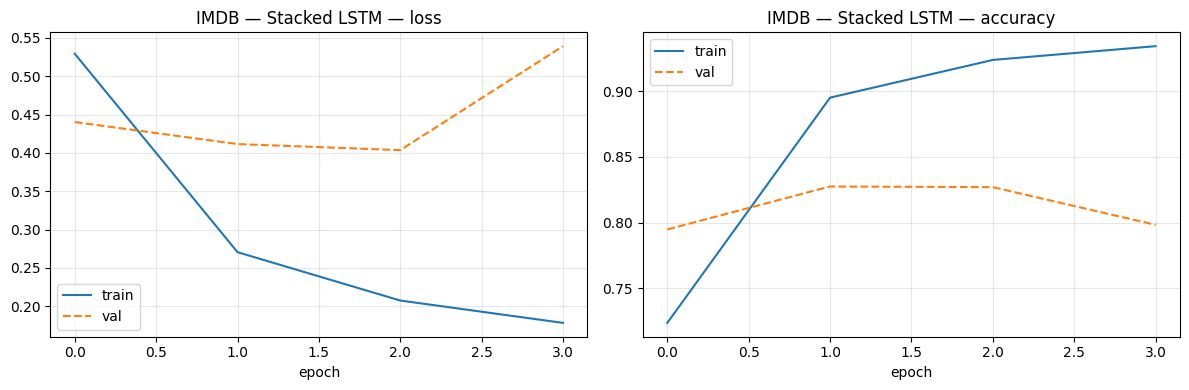

IMDB best test accuracy: 0.827


In [3]:
Xtr, ytr, Xte, yte = R.load_imdb()
cfg = R.imdb_config(); print('vocab', cfg['num_words'], '| maxlen', cfg['maxlen'])

model = keras.Sequential([
    keras.Input((cfg['maxlen'],)),
    layers.Embedding(cfg['num_words'], 32),
    layers.LSTM(32, return_sequences=True),
    layers.LSTM(32),
    layers.Dense(1, activation='sigmoid'),
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()
h = model.fit(Xtr, ytr, validation_data=(Xte, yte), epochs=4, batch_size=64, verbose=0)
plot_history(h, 'accuracy', 'IMDB — Stacked LSTM')
print('IMDB best test accuracy: %.3f' % max(h.history['val_accuracy']))

## Part B — Jena Climate (temperature forecasting)

Two stacked LSTM layers over the weather windows.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, None, 32)       │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,369 (56.13 KB)

 Trainable params: 14,369 (56.13 KB)

 Non-trainable params: 0 (0.00 B)

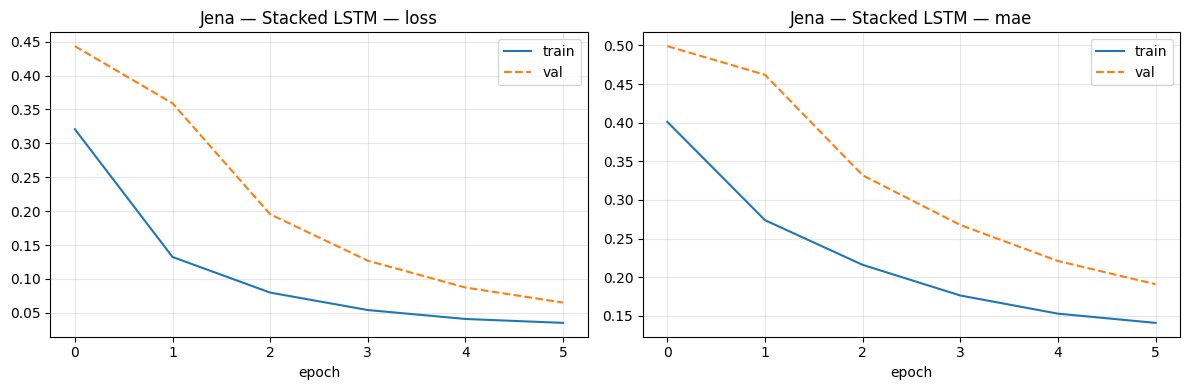

Jena best val MAE: 0.191  (~ 1.65 degC)


In [4]:
train_ds, val_ds, nfeat = R.make_jena_datasets(lookback=48, horizon=1, batch_size=128)
s = R.load_jena_series()

model = keras.Sequential([
    keras.Input((None, nfeat)),
    layers.LSTM(32, return_sequences=True),
    layers.LSTM(32),
    layers.Dense(1),
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()
h = model.fit(train_ds, validation_data=val_ds, epochs=6, verbose=0)
plot_history(h, 'mae', 'Jena — Stacked LSTM')
print('Jena best val MAE: %.3f  (~ %.2f degC)' % (min(h.history['val_mae']), min(h.history['val_mae'])*s['temp_std']))

## Takeaways
- **`return_sequences=True`** on all-but-last recurrent layers is the mechanical rule for stacking — forget it and you get a shape error.
- Depth adds capacity to model layered temporal structure, but on small/easy data it can overfit or simply not help — always compare against the single-layer version.
- Combine with dropout (notebook 07) when a deep stack starts to overfit.
- **Next:** `06_bidirectional`.